In [1]:
from google.colab import files
uploaded = files.upload()

Saving base_sentimento.csv to base_sentimento (1).csv


In [2]:
import pandas as pd
df = pd.read_csv('/content/base_sentimento.csv')
df.head()


,nome_setor,tipo_exame,comentario,nota,data_avaliacao,sentimento_regra
0,Ressonância Magnética,Ressonância Magnética do Joelho,Demora na entrega do laudo.,1,2026-01-05,negativo
1,Ressonância Magnética,Ressonância magnética da coluna,Ambiente limpo e organizado.,2,2025-11-30,negativo
2,Ressonância Magnética,Resssonância Magnética do joelho,Atendimento rápido e eficiente.,1,2026-01-24,negativo
3,Ressonância Magnética,Ressonância Magnética do ombro,Falta de comunicação na recepção.,1,2026-01-02,negativo
4,Ressonância Magnética,Ressonância Magnética do crânio,Falta de comunicação na recepção.,2,2026-01-11,negativo


In [3]:
print(df['nota'].unique())

[1 2 5 3 4]


In [4]:
df.shape

(263, 6)

Temos no DataFrame a variável **comentários** que é o texto

e a variável **sentimento_regra** que é a variável alvo

In [5]:
# separei X e y
x = df ['comentario']
y = df ['sentimento_regra']

In [6]:
# dividi treino e teste
from sklearn.model_selection import train_test_split
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x,y, test_size=0.3, random_state=42
    )

In [7]:

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
x_treino_vec = vectorizer.fit_transform(x_treino)
x_teste_vec = vectorizer.transform(x_teste)

In [8]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()
modelo.fit(x_treino_vec, y_treino)

LogisticRegression()

In [9]:
from sklearn.metrics import classification_report
y_pred = modelo.predict(x_teste_vec)
print (classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

    negativo       0.45      0.49      0.47        35
      neutro       0.00      0.00      0.00        13
    positivo       0.41      0.55      0.47        31

    accuracy                           0.43        79
   macro avg       0.29      0.34      0.31        79
weighted avg       0.36      0.43      0.39        79



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
df['sentimento_regra']. value_counts()

,count
sentimento_regra,
negativo,106
positivo,102
neutro,55


In [11]:
# class_weight = 'balanced' usei porque o dataset apresentou desbalanceamento
# das classe, principalmente na classe neutra que tem menos amostra que as outras,
# prejudicando o recall e o F1-score.
# Ele ajusta automaticamente os pesos das classes de forma inversamente proporcional
# à frequência com que aparecem nos dados de entrada, ajudando o modelo a não dar
# preferência à classe majoritária.
# Usei o max_iter = 1000 para definir o número máximo de iterações que o algoritmo de otimização
# pode executar para convergir.
# Aumentar este valor (o padrão geralmente é 100) pode ajudar o modelo a encontrar uma solução melhor,
# especialmente em conjuntos de dados mais complexos ou quando a convergência é lenta.


modelo = LogisticRegression(class_weight = 'balanced', max_iter=1000)
modelo.fit(x_treino_vec, y_treino)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [12]:
y_pred = modelo.predict(x_teste_vec)
print (classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

    negativo       0.48      0.43      0.45        35
      neutro       0.12      0.15      0.13        13
    positivo       0.42      0.42      0.42        31

    accuracy                           0.38        79
   macro avg       0.34      0.33      0.34        79
weighted avg       0.40      0.38      0.39        79



In [13]:
from sklearn.naive_bayes import MultinomialNB

modelo_nb = MultinomialNB()
modelo_nb.fit(x_treino_vec, y_treino)
y_pred_nb = modelo_nb.predict(x_teste_vec)
print(classification_report(y_teste, y_pred_nb))


              precision    recall  f1-score   support

    negativo       0.48      0.43      0.45        35
      neutro       0.14      0.08      0.10        13
    positivo       0.41      0.55      0.47        31

    accuracy                           0.42        79
   macro avg       0.35      0.35      0.34        79
weighted avg       0.40      0.42      0.40        79



In [14]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [15]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'

)
modelo_rf.fit(x_treino_vec, y_treino)
y_pred_rf = modelo_rf.predict(x_teste_vec)
print(classification_report(y_teste, y_pred_rf))

              precision    recall  f1-score   support

    negativo       0.47      0.51      0.49        35
      neutro       0.12      0.15      0.13        13
    positivo       0.42      0.32      0.36        31

    accuracy                           0.38        79
   macro avg       0.34      0.33      0.33        79
weighted avg       0.39      0.38      0.38        79



In [16]:
from sklearn.metrics import accuracy_score
acc_log = accuracy_score(y_teste, y_pred)
acc_nb = accuracy_score(y_teste, y_pred_nb)
acc_rf = accuracy_score(y_teste, y_pred_rf)
resultados = pd.DataFrame({
    'Modelo':['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Acuracia':[acc_log, acc_nb, acc_rf]
})
resultados

,Modelo,Acuracia
0,Logistic Regression,0.379747
1,Naive Bayes,0.417722
2,Random Forest,0.379747


In [17]:
resultados = resultados.sort_values(by='Acuracia', ascending=False)
resultados.reset_index(drop=True, inplace=True)
resultados

,Modelo,Acuracia
0,Naive Bayes,0.417722
1,Logistic Regression,0.379747
2,Random Forest,0.379747


#**Pré processamento do texto**

Para melhorar o algorítimo


In [18]:
import re
def limpar_texto(texto):
  texto = texto.lower()
  texto = re.sub(r'[^\w\s]','',texto)
  texto = re.sub(r'\d+', '', texto)
  return texto
df['comentario_limpo'] = df['comentario'].apply(limpar_texto)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    min_df=2
)
x = vectorizer.fit_transform(df['comentario_limpo'])

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(class_weight='balanced', max_iter=1000)
scores = cross_val_score(modelo, x, df['sentimento_regra'], cv=5)

print('Acurácias por fold: scores')
print('média:', scores.mean())


Acurácias por fold: scores
média: 0.30805515239477504


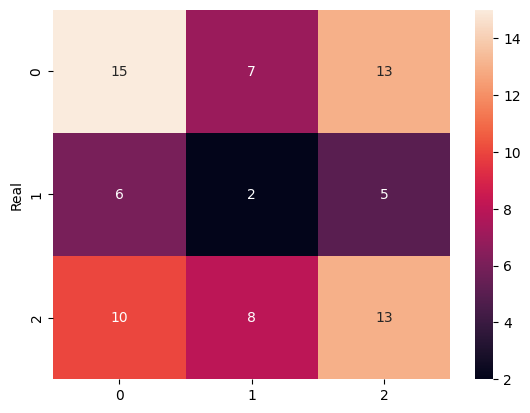

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

modelo.fit(x_treino_vec, y_treino)
y_pred = modelo.predict(x_teste_vec)

cm = confusion_matrix(y_teste, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('')
plt.ylabel('Real')
plt.show()


In [22]:
import numpy as np
modelo.fit(x, df['sentimento_regra'])
coef = modelo.coef_
feature_names = vectorizer.get_feature_names_out()
top_features = np.argsort(coef[0])[-10:]
for i in top_features:
  print (feature_names[i])


eficiente
comunicação na
na recepção
falta de
de comunicação
recepção
falta
atenciosa durante
durante
durante exame


In [23]:
df['sentimento_regra'].value_counts()

,count
sentimento_regra,
negativo,106
positivo,102
neutro,55


In [24]:
df['nota'].value_counts().sort_index()

,count
nota,
1,51
2,55
3,55
4,54
5,48


In [25]:
df = df[df['nota']!=3]


In [26]:
df['nota'].value_counts().sort_index()

,count
nota,
1,51
2,55
4,54
5,48


In [27]:
df["sentimento"]=df['nota'].apply(
    lambda x:0  if x <= 2 else 1
)

In [28]:
df['sentimento']=1 - df['sentimento']

In [29]:
# a nota não está confiável para criar um sentimento, não está consistente
#vou usar somente o rótulo textual(positivo/negativo), pois a nota está inconsistente com o texto.
#pode gerar ruído, piorar o modelo
df.groupby('nota')['comentario'].apply(lambda x: x.iloc[0])

,comentario
nota,
1,Demora na entrega do laudo.
2,Ambiente limpo e organizado.
4,"Ambiente organizado, porém poderia melhorar a ..."
5,Laudo demorou mais do que o esperado.


limpar rótulo, validar dados, garantir coerência, não só treinar o modelo.

In [30]:
#vou corrigir manual, pois o Dataset é pequeno, vou melhorar a qualidade.
# Ver tudo
df[['comentario', 'sentimento']].head(20)

,comentario,sentimento
0,Demora na entrega do laudo.,1
1,Ambiente limpo e organizado.,1
2,Atendimento rápido e eficiente.,1
3,Falta de comunicação na recepção.,1
4,Falta de comunicação na recepção.,1
5,Laudo demorou mais do que o esperado.,0
6,Equipe muito atenciosa durante o exame.,1
7,Demora na entrega do laudo.,0
8,Laudo demorou mais do que o esperado.,1
9,Atendimento rápido e equipe muito atenciosa.,0


In [31]:
#Filtrar Palavras suspeitas

#palavras negativas
df[df['comentario'].str.contains('demora|falta|ruim|péssimo',case=False)]

,nome_setor,tipo_exame,comentario,nota,data_avaliacao,sentimento_regra,comentario_limpo,sentimento
0,Ressonância Magnética,Ressonância Magnética do Joelho,Demora na entrega do laudo.,1,2026-01-05,negativo,demora na entrega do laudo,1
3,Ressonância Magnética,Ressonância Magnética do ombro,Falta de comunicação na recepção.,1,2026-01-02,negativo,falta de comunicação na recepção,1
4,Ressonância Magnética,Ressonância Magnética do crânio,Falta de comunicação na recepção.,2,2026-01-11,negativo,falta de comunicação na recepção,1
7,Ressonância Magnética,Ressonância Magnética do Abdomen,Demora na entrega do laudo.,5,2026-01-03,positivo,demora na entrega do laudo,0
15,Ressonância Magnética,Ressonância Magnética do Abdomen,Falta de comunicação na recepção.,2,2025-12-23,negativo,falta de comunicação na recepção,1
...,...,...,...,...,...,...,...,...
254,Ressonância Magnética,Ressonância Magnética do Abdomen,Demora para realização do exame.,2,2026-01-06,negativo,demora para realização do exame,1
255,Ressonância Magnética,Resssonância Magnética do joelho,Falta de comunicação na recepção.,1,2026-01-05,negativo,falta de comunicação na recepção,1
256,Ressonância Magnética,Ressonância Magnética do Abdomen,Demora na entrega do laudo.,5,2025-11-15,positivo,demora na entrega do laudo,0
259,Ressonância Magnética,Ressonância Magnética do Abdomen,Demora para realização do exame.,5,2026-01-21,positivo,demora para realização do exame,0


In [32]:
#encontrar inconsisitência entre nota e sentimento
#regra lógica: nota 1 e 2 -> negativo(0)
#              nota 4 e 5 -> positivo(1)
#              nota 3 -----> neutro ou ignorar
df["sentimento_regra"] = df['nota'].apply(
    lambda x: 0 if x <= 2 else 1 if x >=4 else None)


In [33]:
# Encontrar onde o sentimento está errado
conflitos = df[df["sentimento"] != df ["sentimento_regra"]]
conflitos [['comentario', 'nota', 'sentimento_regra']]

,comentario,nota,sentimento_regra
0,Demora na entrega do laudo.,1,0
1,Ambiente limpo e organizado.,2,0
2,Atendimento rápido e eficiente.,1,0
3,Falta de comunicação na recepção.,1,0
4,Falta de comunicação na recepção.,2,0
...,...,...,...
258,Atendimento rápido e eficiente.,1,0
259,Demora para realização do exame.,5,1
260,Atendimento rápido e eficiente.,1,0
261,Falta de comunicação na recepção.,1,0



#**Zerar sentimento**
(para resolver o problema de inconsisitência)

In [34]:
#Zerar sentimento
df['sentimento'] = None

In [35]:
#Primeiro criar regra NEGATIVA
df.loc[
    df['comentario'].str.contains(
        'demora|demorou|falta|ruim|péssimo|pessimo|atraso',
        case=False
    ),
    'sentimento'
] = 0

In [36]:
# Criar regra POSITIVA
df.loc[
    df['comentario'].str.contains(
        'excelente|ótimo|otimo|organizado|eficiente|rápido|rapido|atenciosa|limpo',
        case=False
    ),
    'sentimento'
] = 1

# IMPORTANTE: a regra positiva vem depois para sobrescrever quando houver conflito.

In [37]:
# deixando NOTA como verdade final, para deixar 100% consisitente.
df['sentimento'] = df['nota'].apply(
    lambda x: 0 if x <= 2 else 1 if x >= 4 else None)

In [38]:
df[['comentario','nota','sentimento']].head(20)

,comentario,nota,sentimento
0,Demora na entrega do laudo.,1,0
1,Ambiente limpo e organizado.,2,0
2,Atendimento rápido e eficiente.,1,0
3,Falta de comunicação na recepção.,1,0
4,Falta de comunicação na recepção.,2,0
5,Laudo demorou mais do que o esperado.,5,1
6,Equipe muito atenciosa durante o exame.,2,0
7,Demora na entrega do laudo.,5,1
8,Laudo demorou mais do que o esperado.,2,0
9,Atendimento rápido e equipe muito atenciosa.,5,1


In [39]:
#df= pd.read_csv('base_sentimentos.csv')

In [40]:
#ignorar a nota
df_hospital= df = df[['comentario', 'sentimento_regra']]

In [41]:
print(df_hospital.columns)

Index(['comentario', 'sentimento_regra'], dtype='object')


In [42]:
# identificar os rótulos errados
df_hospital['sentimento_texto'] = None
df_hospital.loc[df_hospital['comentario'].str.contains(
    'demora|demorou|falta|ruim|péssimo|pessimo|atraso',
    case=False
    ), 'sentimento_texto'] = 0


In [43]:

df_hospital.loc[df_hospital['comentario'].str.contains(
      'excelente|ótimo|otimo|organizado|eficiente|rápido|rapido|atenciosa|limpo',
        case=False
    ),
    'sentimento_texto'
] = 1

In [44]:
print(df_hospital.columns)

Index(['comentario', 'sentimento_regra', 'sentimento_texto'], dtype='object')


In [45]:
df_hospital[df_hospital['sentimento_regra'] != df_hospital['sentimento_texto']]

,comentario,sentimento_regra,sentimento_texto
1,Ambiente limpo e organizado.,0,1
2,Atendimento rápido e eficiente.,0,1
5,Laudo demorou mais do que o esperado.,1,0
6,Equipe muito atenciosa durante o exame.,0,1
7,Demora na entrega do laudo.,1,0
...,...,...,...
252,Atendimento rápido e eficiente.,0,1
256,Demora na entrega do laudo.,1,0
258,Atendimento rápido e eficiente.,0,1
259,Demora para realização do exame.,1,0


In [46]:
print(df_hospital.columns)

Index(['comentario', 'sentimento_regra', 'sentimento_texto'], dtype='object')


In [47]:
df_hospital.drop(columns=['sentimento_regra'], inplace=True)

In [48]:
print(df_hospital.columns)

Index(['comentario', 'sentimento_texto'], dtype='object')


In [49]:
df_hospital = df_hospital[['comentario', 'sentimento_texto']]
df_hospital = df_hospital.rename(columns={
    'comentario': 'comentario', 'sentimento_texto':'sentimento'
     })

In [50]:
print(df_hospital.columns)

Index(['comentario', 'sentimento'], dtype='object')


In [51]:
df_hospital['sentimento'].unique()

array([0, 1], dtype=object)

In [52]:
df_hospital['sentimento'].value_counts()

,count
sentimento,
1,105
0,103


In [53]:
df_hospital[['comentario','sentimento']].head(20)

,comentario,sentimento
0,Demora na entrega do laudo.,0
1,Ambiente limpo e organizado.,1
2,Atendimento rápido e eficiente.,1
3,Falta de comunicação na recepção.,0
4,Falta de comunicação na recepção.,0
5,Laudo demorou mais do que o esperado.,0
6,Equipe muito atenciosa durante o exame.,1
7,Demora na entrega do laudo.,0
8,Laudo demorou mais do que o esperado.,0
9,Atendimento rápido e equipe muito atenciosa.,1


#**Hospital**

In [54]:
hospital = pd.read_csv('hospital.csv')
hospital.head()

,Feedback,Sentiment Label,Ratings,Unnamed: 3
0,Good and clean hospital. There is great team o...,1,5,NaN
1,Had a really bad experience during discharge. ...,1,5,NaN
2,I have visited to take my second dose and Proc...,1,4,NaN
3,That person was slightly clueless and offered...,1,3,NaN
4,There is great team of doctors and good OT fac...,0,1,NaN


In [55]:
!pip install deep_translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.0 MB/s eta 0:00:00


In [57]:
from deep_translator import GoogleTranslator
translator = GoogleTranslator(source='auto', target='pt')
hospital['comentario_pt'] = hospital['Feedback'].apply(
    lambda x: translator.translate(x)
)

In [59]:
hospital.head()

,Feedback,Sentiment Label,Ratings,Unnamed: 3,comentario_pt
0,Good and clean hospital. There is great team o...,1,5,NaN,Hospital bom e limpo. Há uma grande equipe de ...
1,Had a really bad experience during discharge. ...,1,5,NaN,Tive uma experiência muito ruim durante a alta...
2,I have visited to take my second dose and Proc...,1,4,NaN,Visitei para tomar minha segunda dose e o proc...
3,That person was slightly clueless and offered...,1,3,NaN,Essa pessoa era um pouco sem noção e ofereceu ...
4,There is great team of doctors and good OT fac...,0,1,NaN,Há uma grande equipe de médicos e boas instala...


In [60]:
hospital = hospital[hospital['Ratings'] != 3]

In [61]:
hospital["Sentiment Label"]=hospital['Ratings'].apply(lambda x: 0 if x <= 2 else 1)



In [62]:
hospital['sentimento_texto'] = hospital['Sentiment Label']

In [63]:
print(hospital.columns)

Index(['Feedback', 'Sentiment Label', 'Ratings', 'Unnamed: 3', 'comentario_pt',
       'sentimento_texto'],
      dtype='object')


In [64]:
hospital['Sentiment Label'].unique()

array([1, 0])

In [65]:
hospital['sentimento_texto'].unique()

array([1, 0])

In [66]:
hospital = hospital[hospital['Sentiment Label'] == hospital['sentimento_texto']]

In [67]:
inconsistentes = hospital[hospital['Sentiment Label'] != hospital['sentimento_texto']]

In [68]:
inconsistentes[['comentario_pt', 'Sentiment Label', 'sentimento_texto']]

,comentario_pt,Sentiment Label,sentimento_texto


In [69]:
len(inconsistentes)

0

In [70]:
inconsistentes.shape

(0, 6)

In [71]:
print(hospital.columns)

Index(['Feedback', 'Sentiment Label', 'Ratings', 'Unnamed: 3', 'comentario_pt',
       'sentimento_texto'],
      dtype='object')


In [72]:
hospital.head(20)

,Feedback,Sentiment Label,Ratings,Unnamed: 3,comentario_pt,sentimento_texto
0,Good and clean hospital. There is great team o...,1,5,NaN,Hospital bom e limpo. Há uma grande equipe de ...,1
1,Had a really bad experience during discharge. ...,1,5,NaN,Tive uma experiência muito ruim durante a alta...,1
2,I have visited to take my second dose and Proc...,1,4,NaN,Visitei para tomar minha segunda dose e o proc...,1
4,There is great team of doctors and good OT fac...,0,1,NaN,Há uma grande equipe de médicos e boas instala...,0
5,My primary concern arose from the insistence o...,0,2,NaN,A minha principal preocupação surgiu da insist...,0
6,Good and clean hospital. The medical faciliti...,1,5,NaN,Hospital bom e limpo. As instalações médicas ...,1
8,"Over all experience was good, starting from re...",1,5,NaN,"No geral a experiência foi boa, desde a recepç...",1
9,"However,the services of front office (where we...",1,5,NaN,"No entanto, os serviços de front office (onde ...",1
10,"Other wise no complaints, fully satisfied.",1,4,NaN,"Caso contrário, sem queixas, totalmente satisf...",1
11,Thanks to the Emergency doctor abhishek and Th...,1,5,NaN,Obrigado ao médico de emergência Abhishek e ao...,1


In [73]:
hospital = hospital.rename(columns={
    'comentario_pt': 'comentario',
    'sentimento_texto': 'sentimento'
})

In [74]:
print(hospital.columns)

Index(['Feedback', 'Sentiment Label', 'Ratings', 'Unnamed: 3', 'comentario',
       'sentimento'],
      dtype='object')


# Antes de juntar eu garanti que o formato estivesse correto.

In [75]:
hospital['comentario'] = hospital['comentario'].astype(str)
hospital['sentimento'] = hospital['sentimento'].astype(int)

In [76]:
hospital = hospital[['comentario', 'sentimento']]

In [77]:
print(df_hospital.columns)

Index(['comentario', 'sentimento'], dtype='object')


In [78]:
print(hospital.columns)

Index(['comentario', 'sentimento'], dtype='object')


In [79]:
hospital.tail(20)

,comentario,sentimento
973,"O hospital Nu é muito bom, cuidadoso e gentil,...",1
974,um dos funcionários do hospital pegou meu celu...,0
975,experiência ruim No serviço não quero ser tend...,0
976,Tivemos uma experiência maravilhosa no NU Hosp...,1
977,Os serviços que recebemos do hospital NU são e...,1
978,A equipe do hospital NU tem sido muito prestat...,1
979,"No geral, tivemos uma ótima experiência sem co...",0
981,Boas equipes de suporte técnico nos ajudaram d...,1
982,Há um ano percebi que não há cooperação da equ...,0
983,A expectativa é que consigamos consultar o méd...,0


Antes de juntar os datasets preciso validar os sentimentos, pois se não estiver correto o modelo aprende errado.

"Validei a consistência dos rótulos e garanti que ambos os datasets seguem o mesmo padrão (1 positivo, 0 negativo), evitando viés no modelo."



In [80]:
#ver distribuição dos sentimentos
df_hospital['sentimento'].value_counts()

,count
sentimento,
1,105
0,103


In [81]:
hospital['sentimento'].value_counts()

,count
sentimento,
1,605
0,268


In [82]:
df_hospital.sample(5)

,comentario,sentimento
55,Ambiente limpo e organizado.,1
152,Atendimento rápido e eficiente.,1
44,Equipe muito atenciosa durante o exame.,1
107,Equipe muito atenciosa durante o exame.,1
125,Demora para realização do exame.,0


In [83]:
hospital.sample(5)

,comentario,sentimento
340,O paciente tem esperança e tem total fé de que...,1
918,Os funcionários são bem comportados e cooperat...,1
766,Consultou o cardiologista Dr. Chandan Excelent...,1
829,"Sem gerenciamento adequado, eles colocarão sua...",0
990,Um prestador de cuidados de saúde de excelente...,1


In [84]:
#df_final = pd.concat([df_hospital,hospital], ignore_index=True)

In [85]:
df_hospital.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 262
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comentario  208 non-null    object
 1   sentimento  208 non-null    object
dtypes: object(2)
memory usage: 4.9+ KB


In [86]:
hospital.info()

<class 'pandas.core.frame.DataFrame'>
Index: 873 entries, 0 to 995
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comentario  873 non-null    object
 1   sentimento  873 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 20.5+ KB


In [87]:
df_hospital['comentario'] = df_hospital['comentario'].astype(str)
df_hospital['sentimento'] = df_hospital['sentimento'].astype(int)

In [88]:
df_hospital.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 262
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comentario  208 non-null    object
 1   sentimento  208 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.9+ KB


#Juntando os datasets

In [89]:
df_final = pd.concat([df_hospital, hospital], ignore_index=True)

# Conferir resultado final

In [90]:
df_final.shape

(1081, 2)

In [91]:
df_final['sentimento'].value_counts()

,count
sentimento,
1,710
0,371


In [92]:
df_final.isnull().sum()

,0
comentario,0
sentimento,0


In [93]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comentario  1081 non-null   object
 1   sentimento  1081 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 17.0+ KB


In [94]:
df_final = df_final.dropna(subset=['comentario', 'sentimento'])

Salvando dataset final como csv, pois terei o dataset já tratado, não vou

precisar traduzir toda vez, terei base persistente. Poderei usar diretamente no ML e Tableau.


In [95]:
df_final.to_csv('dataset_final.csv', index=False)

In [96]:
from google.colab import files
files.download('dataset_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [100]:
df_final.to_csv('/content/drive/MyDrive/dataset_final.csv', index=False)

In [101]:
df_final = pd.read_csv('dataset_final.csv')

In [102]:
df_final.head()

,comentario,sentimento
0,Demora na entrega do laudo.,0
1,Ambiente limpo e organizado.,1
2,Atendimento rápido e eficiente.,1
3,Falta de comunicação na recepção.,0
4,Falta de comunicação na recepção.,0


In [103]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comentario  1081 non-null   object
 1   sentimento  1081 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 17.0+ KB


In [104]:
from sklearn.model_selection import train_test_split
X=df_final['comentario']
y=df_final['sentimento']
X_train, X_test, y_train, y_test= train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression())
])

In [106]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', LogisticRegression())])

In [107]:
y_pred = pipeline.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

print(classification_report(y_test, y_pred))

Acurácia: 0.8986175115207373
              precision    recall  f1-score   support

           0       0.98      0.71      0.83        73
           1       0.87      0.99      0.93       144

    accuracy                           0.90       217
   macro avg       0.93      0.85      0.88       217
weighted avg       0.91      0.90      0.89       217



In [109]:
df_final['predicao']= pipeline.predict(df_final['comentario'])


In [110]:
df_final.to_csv('dataset_modelo.csv',index=False)

In [111]:
from google.colab import files
files.download('dataset_modelo.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>